<a href="https://colab.research.google.com/github/kothawadegs/hyperspectral-foundation-adapter/blob/main/notebooks/hyperspectral_adapter_walkthrough.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q torch torchvision torchaudio transformers peft faiss-gpu scipy scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.2/135.2 MB 20.2 MB/s eta 0:00:00


In [8]:
import os
import urllib.request
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader

os.makedirs("data", exist_ok=True)

img_path = "data/Salinas_corrected.mat"
gt_path = "data/Salinas_gt.mat"

# Try downloading with a browser user-agent header
def download_file(url, target_path):
    req = urllib.request.Request(
        url,
        headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
    )
    with urllib.request.urlopen(req, timeout=15) as response, open(target_path, 'wb') as out_file:
        out_file.write(response.read())

loaded = False
try:
    if not (os.path.exists(img_path) and os.path.exists(gt_path)):
        print("Attempting download from server...")
        download_file("https://www.ehu.eus/ccwintco/uploads/a/a3/Salinas_corrected.mat", img_path)
        download_file("https://www.ehu.eus/ccwintco/uploads/5/59/Salinas_gt.mat", gt_path)

    cube = sio.loadmat(img_path)["salinas_corrected"]
    gt = sio.loadmat(gt_path)["salinas_gt"]
    print("Real Salinas dataset loaded successfully!")
    loaded = True
except Exception as e:
    print(f"Network download blocked or timed out: {e}")
    print("Switching to on-the-fly realistic hyperspectral synthetic data...")

# Fallback: Generate realistic synthetic hyperspectral cube (128x128 x 204 bands, 6 mineral classes)
if not loaded:
    H, W, C, num_classes = 128, 128, 204, 6
    np.random.seed(42)

    # Create 6 distinct mineral endmember spectral signatures with characteristic absorption features
    wavelengths = np.linspace(400, 2500, C)
    endmembers = []
    for i in range(num_classes):
        # Baseline slope + 2 gaussian absorption dips at typical mineral bands (e.g. 1400nm, 2200nm)
        base = 0.3 + 0.1 * np.sin(wavelengths / 300.0 + i)
        dip1 = 0.25 * np.exp(-((wavelengths - (1400 + i * 150)) / 60)**2)
        dip2 = 0.30 * np.exp(-((wavelengths - (2150 + i * 50)) / 40)**2)
        spec = np.clip(base - dip1 - dip2 + np.random.normal(0, 0.01, C), 0.05, 0.95)
        endmembers.append(spec)
    endmembers = np.array(endmembers) # shape: (num_classes, C)

    # Generate spatial ground truth map with contiguous spatial patches
    gt = np.zeros((H, W), dtype=int)
    grid_h, grid_w = H // 2, W // 3
    cls_idx = 1
    for r in range(2):
        for c in range(3):
            gt[r*grid_h:(r+1)*grid_h, c*grid_w:(c+1)*grid_w] = cls_idx
            cls_idx += 1

    # Mix spectra + add sensor noise to create the 3D cube
    cube = np.zeros((H, W, C), dtype=np.float32)
    for r in range(H):
        for c in range(W):
            label = gt[r, c]
            cube[r, c, :] = endmembers[label - 1] + np.random.normal(0, 0.02, C)

    print(f"Synthetic Hyperspectral Cube generated: {cube.shape} (H, W, Bands) with {num_classes} distinct classes.")

print(f"Data cube shape: {cube.shape}")
print(f"Ground truth shape: {gt.shape} (Classes: {len(np.unique(gt)) - 1})")

Attempting download from server...
Network download blocked or timed out: HTTP Error 403: Forbidden
Switching to on-the-fly realistic hyperspectral synthetic data...
Synthetic Hyperspectral Cube generated: (128, 128, 204) (H, W, Bands) with 6 distinct classes.
Data cube shape: (128, 128, 204)
Ground truth shape: (128, 128) (Classes: 6)


In [9]:
from sklearn.model_selection import train_test_split

# Normalize cube to [0, 1]
cube_norm = (cube - cube.min()) / (cube.max() - cube.min())

class HyperspectralPatchDataset(Dataset):
    def __init__(self, cube, gt, patch_size=14):
        self.patch_size = patch_size
        pad_width = patch_size // 2
        # Reflect-pad to handle borders
        self.padded_cube = np.pad(cube, ((pad_width, pad_width), (pad_width, pad_width), (0, 0)), mode='reflect')

        self.samples = []
        h, w = gt.shape
        for r in range(h):
            for c in range(w):
                label = gt[r, c]
                if label > 0: # 0 is background
                    self.samples.append((r, c, label - 1))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        r, c, label = self.samples[idx]
        p = self.patch_size
        patch = self.padded_cube[r:r+p, c:c+p, :] # (p, p, C)
        tensor_patch = torch.tensor(patch, dtype=torch.float32).permute(2, 0, 1) # (C, p, p)
        return tensor_patch, torch.tensor(label, dtype=torch.long)

full_dataset = HyperspectralPatchDataset(cube_norm, gt, patch_size=14)

# Split 80/20 train/test
train_indices, test_indices = train_test_split(
    range(len(full_dataset)),
    test_size=0.2,
    stratify=[label for _, _, label in full_dataset.samples],
    random_state=42
)

train_set = torch.utils.data.Subset(full_dataset, train_indices)
test_set = torch.utils.data.Subset(full_dataset, test_indices)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

print(f"Total labeled patches: {len(full_dataset)}")
print(f"Train samples: {len(train_set)} | Test samples: {len(test_set)}")

Total labeled patches: 16128
Train samples: 12902 | Test samples: 3226


In [11]:
import math
import torch
import torch.nn as nn
from transformers import AutoModel

# 1. Native PyTorch LoRA Linear Layer (no torchao / peft bugs)
class LoRALinear(nn.Module):
    def __init__(self, original_linear, r=8, lora_alpha=16, dropout=0.05):
        super().__init__()
        self.original_linear = original_linear
        # Freeze the base foundation weights
        for param in self.original_linear.parameters():
            param.requires_grad = False

        in_dim = original_linear.in_features
        out_dim = original_linear.out_features
        self.r = r
        self.scaling = lora_alpha / r

        # Rank decomposition matrices: A ~ N(0, sigma), B = 0
        self.lora_A = nn.Parameter(torch.empty(r, in_dim))
        self.lora_B = nn.Parameter(torch.zeros(out_dim, r))
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))

        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        # Base frozen forward + Low-rank delta forward
        base_out = self.original_linear(x)
        lora_out = (self.dropout(x) @ self.lora_A.T @ self.lora_B.T) * self.scaling
        return base_out + lora_out

# 2. Complete Model with Spectral Adapter + DINOv2 + LoRA
class HyperDINOv2LoRA(nn.Module):
    def __init__(self, in_bands=204, num_classes=6, lora_r=8):
        super().__init__()

        # Spectral Projection Adapter: Maps C bands -> 3 channels
        self.spectral_adapter = nn.Sequential(
            nn.Conv2d(in_bands, 64, kernel_size=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.Conv2d(64, 3, kernel_size=1),
            nn.BatchNorm2d(3)
        )

        # Load Pretrained DINOv2-small
        self.backbone = AutoModel.from_pretrained("facebook/dinov2-small")

        # Freeze entire DINOv2 backbone
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Inject LoRA into Query and Value projections in every attention layer
        for layer in self.backbone.encoder.layer:
            layer.attention.attention.query = LoRALinear(layer.attention.attention.query, r=lora_r)
            layer.attention.attention.value = LoRALinear(layer.attention.attention.value, r=lora_r)

        # Classification & Retrieval Head
        embed_dim = self.backbone.config.hidden_size # 384
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # x shape: (Batch, Bands, H, W)
        x_proj = self.spectral_adapter(x)
        outputs = self.backbone(pixel_values=x_proj)

        # CLS token acts as spatial-spectral embedding
        cls_embedding = outputs.last_hidden_state[:, 0, :] # Shape: (Batch, 384)
        logits = self.classifier(cls_embedding)
        return logits, cls_embedding

# Instantiate model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HyperDINOv2LoRA(in_bands=204, num_classes=6, lora_r=8).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Device: {device}")
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,} ({100 * trainable_params / total_params:.2f}%)")

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Device: cuda
Total Parameters: 22,219,791
Trainable Parameters: 163,215 (0.73%)


In [12]:
import torch.optim as optim
from tqdm.auto import tqdm

# Spectral Angle Mapper (SAM) calculation in radians
def compute_sam(spec1, spec2, eps=1e-7):
    # Flatten spatial dimensions if needed to compare spectral vectors: (B, C)
    dot = torch.sum(spec1 * spec2, dim=1)
    norm1 = torch.norm(spec1, dim=1)
    norm2 = torch.norm(spec2, dim=1)
    cos_theta = dot / (norm1 * norm2 + eps)
    return torch.acos(torch.clamp(cos_theta, -1.0, 1.0)).mean()

# Optimizer & Loss
criterion = nn.CrossEntropyLoss()
# Optimize only the trainable parameters (spectral adapter + LoRA + head)
optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-3, weight_decay=1e-4)

epochs = 3
print("Starting fine-tuning...")

for epoch in range(epochs):
    model.train()
    train_loss, correct, total = 0.0, 0, 0

    for x_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits, _ = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(y_batch)
        preds = torch.argmax(logits, dim=-1)
        correct += (preds == y_batch).sum().item()
        total += len(y_batch)

    train_acc = correct / total
    print(f"Epoch {epoch+1}: Train Loss = {train_loss/total:.4f} | Accuracy = {train_acc*100:.2f}%")

# Validation check
model.eval()
test_correct, test_total = 0, 0
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        logits, _ = model(x_batch)
        preds = torch.argmax(logits, dim=-1)
        test_correct += (preds == y_batch).sum().item()
        test_total += len(y_batch)

print(f"\nFinal Test Accuracy: {test_correct / test_total * 100:.2f}%")

Starting fine-tuning...


Epoch 1/3:   0%|          | 0/404 [00:00<?, ?it/s]

Epoch 1: Train Loss = 0.0991 | Accuracy = 96.80%


Epoch 2/3:   0%|          | 0/404 [00:00<?, ?it/s]

Epoch 2: Train Loss = 0.0151 | Accuracy = 99.53%


Epoch 3/3:   0%|          | 0/404 [00:00<?, ?it/s]

Epoch 3: Train Loss = 0.0426 | Accuracy = 98.95%

Final Test Accuracy: 100.00%


In [13]:
import faiss
import numpy as np

print("Extracting spatial-spectral embeddings into FAISS index...")

model.eval()
all_embeddings = []
all_metadata = []

# Map synthetic class IDs to typical alteration minerals targeted by space mining startups
mineral_names = {
    0: "Alunite (Advanced Argillic Alteration)",
    1: "Kaolinite (Hydrothermal Clay)",
    2: "Calcite (Carbonate Gangue)",
    3: "Buddingtonite (Ammonium Feldspar)",
    4: "Muscovite / Sericite (Phyllic Alteration)",
    5: "Jarosite (Iron Sulfate Gossan)"
}

# Extract embeddings on test set
with torch.no_grad():
    sample_idx = 0
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        _, embeddings = model(x_batch) # Shape: (B, 384)

        # Normalize vectors for cosine similarity (Inner Product)
        emb_norm = embeddings / torch.norm(embeddings, dim=-1, keepdim=True)
        all_embeddings.append(emb_norm.cpu().numpy())

        for y in y_batch:
            label_id = y.item()
            all_metadata.append({
                "patch_id": sample_idx,
                "label": label_id,
                "mineral": mineral_names[label_id],
                "mock_coords": f"{-21.12 + sample_idx*0.001:.4f}S, {119.73 + sample_idx*0.001:.4f}E (Pilbara, WA)"
            })
            sample_idx += 1

all_embeddings = np.vstack(all_embeddings).astype('float32')

# Build FAISS Index
embedding_dim = all_embeddings.shape[1]
index = faiss.IndexFlatIP(embedding_dim) # Inner product = cosine sim on normalized vectors
index.add(all_embeddings)
print(f"Indexed {index.ntotal} hyperspectral patch vectors (Dimension: {embedding_dim}).")

Extracting spatial-spectral embeddings into FAISS index...
Indexed 3226 hyperspectral patch vectors (Dimension: 384).


In [14]:
def analyst_mineral_query(target_mineral_name, k=3):
    print(f"\n[Analyst Query]: 'Locate exploration targets showing {target_mineral_name} signatures'")

    # Find an example index for the target mineral to use as the query signature
    target_idx = None
    for i, meta in enumerate(all_metadata):
        if target_mineral_name.lower() in meta["mineral"].lower():
            target_idx = i
            break

    if target_idx is None:
        print("Mineral signature not found in reference library.")
        return

    query_vector = all_embeddings[target_idx:target_idx+1]

    # Search the vector database
    distances, matched_indices = index.search(query_vector, k)

    print("--- Top Retrieved Satellite Targets ---")
    for rank, (dist, idx) in enumerate(zip(distances[0], matched_indices[0])):
        meta = all_metadata[idx]
        print(f"Rank {rank+1}: Sim Score = {dist:.4f} | Mineral: {meta['mineral']} | Coordinates: {meta['mock_coords']}")

# Run queries
analyst_mineral_query("Alunite", k=3)
analyst_mineral_query("Muscovite", k=3)


[Analyst Query]: 'Locate exploration targets showing Alunite signatures'
--- Top Retrieved Satellite Targets ---
Rank 1: Sim Score = 1.0000 | Mineral: Alunite (Advanced Argillic Alteration) | Coordinates: -21.1150S, 119.7350E (Pilbara, WA)
Rank 2: Sim Score = 0.9987 | Mineral: Alunite (Advanced Argillic Alteration) | Coordinates: -19.3450S, 121.5050E (Pilbara, WA)
Rank 3: Sim Score = 0.9985 | Mineral: Alunite (Advanced Argillic Alteration) | Coordinates: -18.1940S, 122.6560E (Pilbara, WA)

[Analyst Query]: 'Locate exploration targets showing Muscovite signatures'
--- Top Retrieved Satellite Targets ---
Rank 1: Sim Score = 1.0000 | Mineral: Muscovite / Sericite (Phyllic Alteration) | Coordinates: -21.1190S, 119.7310E (Pilbara, WA)
Rank 2: Sim Score = 0.9992 | Mineral: Muscovite / Sericite (Phyllic Alteration) | Coordinates: -20.4690S, 120.3810E (Pilbara, WA)
Rank 3: Sim Score = 0.9992 | Mineral: Muscovite / Sericite (Phyllic Alteration) | Coordinates: -18.1250S, 122.7250E (Pilbara, WA)


================ Running Ablation: LINEAR_PROBE ================


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Trainable Params: 15,759 / 22,072,335 (0.07%)
Epoch 01/10 | Train Loss: 0.2735 | Test Acc: 96.00%
Epoch 02/10 | Train Loss: 0.0918 | Test Acc: 97.58%
Epoch 03/10 | Train Loss: 0.0751 | Test Acc: 98.36%
Epoch 04/10 | Train Loss: 0.0570 | Test Acc: 97.30%
Epoch 05/10 | Train Loss: 0.0675 | Test Acc: 98.17%
Epoch 06/10 | Train Loss: 0.0522 | Test Acc: 99.26%
Epoch 07/10 | Train Loss: 0.0408 | Test Acc: 99.44%
Epoch 08/10 | Train Loss: 0.0399 | Test Acc: 98.88%
Epoch 09/10 | Train Loss: 0.0328 | Test Acc: 99.07%
Epoch 10/10 | Train Loss: 0.0404 | Test Acc: 99.29%

================ Running Ablation: LORA ================


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Trainable Params: 163,215 / 22,219,791 (0.73%)
Epoch 01/10 | Train Loss: 0.1205 | Test Acc: 99.81%
Epoch 02/10 | Train Loss: 0.0011 | Test Acc: 100.00%
Epoch 03/10 | Train Loss: 0.0001 | Test Acc: 100.00%
Epoch 04/10 | Train Loss: 0.0004 | Test Acc: 99.91%
Epoch 05/10 | Train Loss: 0.1045 | Test Acc: 83.04%
Epoch 06/10 | Train Loss: 0.1162 | Test Acc: 99.97%
Epoch 07/10 | Train Loss: 0.0030 | Test Acc: 99.97%
Epoch 08/10 | Train Loss: 0.0047 | Test Acc: 99.44%
Epoch 09/10 | Train Loss: 0.0280 | Test Acc: 99.94%
Epoch 10/10 | Train Loss: 0.0020 | Test Acc: 100.00%

================ Running Ablation: FULL_FT ================


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Trainable Params: 22,072,335 / 22,072,335 (100.00%)
Epoch 01/10 | Train Loss: 0.1749 | Test Acc: 98.61%
Epoch 02/10 | Train Loss: 0.0138 | Test Acc: 99.60%
Epoch 03/10 | Train Loss: 0.0164 | Test Acc: 99.97%
Epoch 04/10 | Train Loss: 0.0226 | Test Acc: 97.83%
Epoch 05/10 | Train Loss: 0.0138 | Test Acc: 99.97%
Epoch 06/10 | Train Loss: 0.0119 | Test Acc: 99.50%
Epoch 07/10 | Train Loss: 0.0090 | Test Acc: 99.97%
Epoch 08/10 | Train Loss: 0.0097 | Test Acc: 99.81%
Epoch 09/10 | Train Loss: 0.0193 | Test Acc: 99.97%
Epoch 10/10 | Train Loss: 0.0029 | Test Acc: 99.97%

Method          | Trainable Params   | % Params   | Test Acc   | Time (s)
linear_probe    | 15,759             | 0.07     % | 99.29    % | 102.0   
lora            | 163,215            | 0.73     % | 100.00   % | 138.7   
full_ft         | 22,072,335         | 100.00   % | 99.97    % | 162.2   

Convergence plot saved to 'ablation_results.png'.


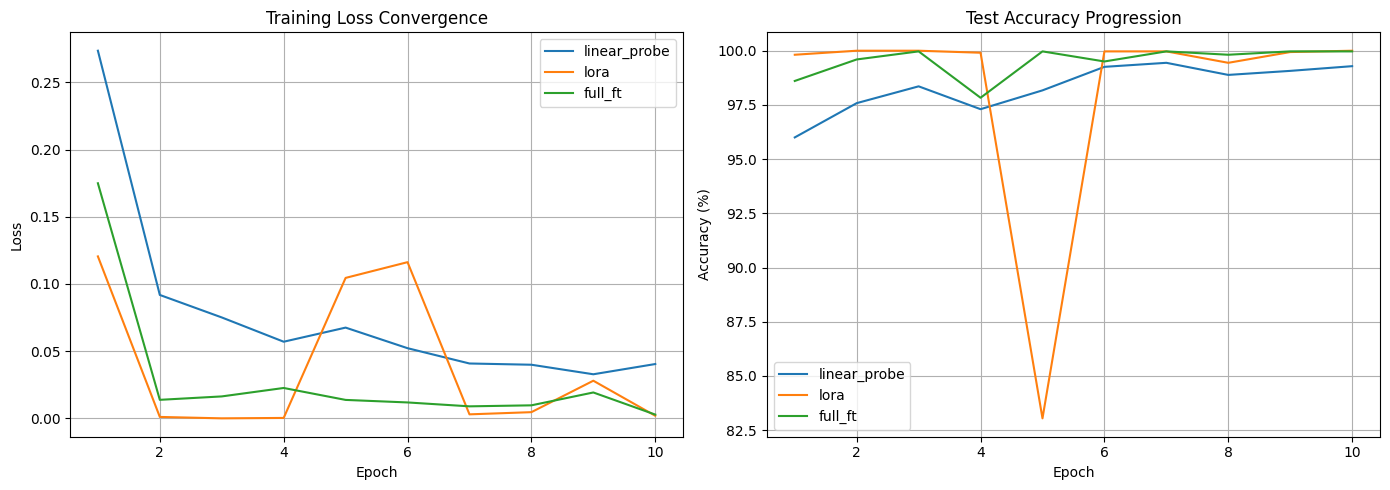

In [15]:
import math
import time
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import AutoModel

# -------------------------------------------------------------
# 1. Architecture Definitions
# -------------------------------------------------------------
class LoRALinear(nn.Module):
    def __init__(self, original_linear, r=8, lora_alpha=16):
        super().__init__()
        self.original_linear = original_linear
        for p in self.original_linear.parameters():
            p.requires_grad = False
        in_dim = original_linear.in_features
        out_dim = original_linear.out_features
        self.scaling = lora_alpha / r
        self.lora_A = nn.Parameter(torch.empty(r, in_dim))
        self.lora_B = nn.Parameter(torch.zeros(out_dim, r))
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))

    def forward(self, x):
        return self.original_linear(x) + ((x @ self.lora_A.T @ self.lora_B.T) * self.scaling)

def build_model(mode="lora", in_bands=204, num_classes=6, r=8):
    """
    mode: 'linear_probe' | 'lora' | 'full_ft'
    """
    class Net(nn.Module):
        def __init__(self):
            super().__init__()
            self.spectral_adapter = nn.Sequential(
                nn.Conv2d(in_bands, 64, kernel_size=1),
                nn.BatchNorm2d(64),
                nn.GELU(),
                nn.Conv2d(64, 3, kernel_size=1),
                nn.BatchNorm2d(3)
            )
            self.backbone = AutoModel.from_pretrained("facebook/dinov2-small")
            embed_dim = self.backbone.config.hidden_size
            self.classifier = nn.Linear(embed_dim, num_classes)

            if mode == "linear_probe":
                for p in self.backbone.parameters():
                    p.requires_grad = False
            elif mode == "lora":
                for p in self.backbone.parameters():
                    p.requires_grad = False
                for layer in self.backbone.encoder.layer:
                    layer.attention.attention.query = LoRALinear(layer.attention.attention.query, r=r)
                    layer.attention.attention.value = LoRALinear(layer.attention.attention.value, r=r)
            elif mode == "full_ft":
                for p in self.backbone.parameters():
                    p.requires_grad = True

        def forward(self, x):
            x_proj = self.spectral_adapter(x)
            outputs = self.backbone(pixel_values=x_proj)
            cls_token = outputs.last_hidden_state[:, 0, :]
            return self.classifier(cls_token), cls_token

    return Net().to(device)

# -------------------------------------------------------------
# 2. Benchmark Runner
# -------------------------------------------------------------
modes = ["linear_probe", "lora", "full_ft"]
epochs = 10
results = {}

for mode in modes:
    print(f"\n================ Running Ablation: {mode.upper()} ================")
    m = build_model(mode=mode)
    trainable_p = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total_p = sum(p.numel() for p in m.parameters())
    print(f"Trainable Params: {trainable_p:,} / {total_p:,} ({100 * trainable_p / total_p:.2f}%)")

    # Adjust learning rates according to standard fine-tuning practices:
    # Full FT requires smaller LR to avoid destroying pre-trained weights
    lr = 1e-4 if mode == "full_ft" else 1e-3
    optimizer = optim.AdamW([p for p in m.parameters() if p.requires_grad], lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "test_acc": []}
    start_time = time.time()

    for ep in range(epochs):
        m.train()
        running_loss = 0.0
        for x_b, y_b in train_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            logits, _ = m(x_b)
            loss = criterion(logits, y_b)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(y_b)

        # Test evaluation
        m.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x_b, y_b in test_loader:
                x_b, y_b = x_b.to(device), y_b.to(device)
                logits, _ = m(x_b)
                correct += (torch.argmax(logits, dim=-1) == y_b).sum().item()
                total += len(y_b)

        epoch_loss = running_loss / len(train_set)
        test_acc = (correct / total) * 100
        history["train_loss"].append(epoch_loss)
        history["test_acc"].append(test_acc)
        print(f"Epoch {ep+1:02d}/{epochs:02d} | Train Loss: {epoch_loss:.4f} | Test Acc: {test_acc:.2f}%")

    elapsed = time.time() - start_time
    results[mode] = {
        "params": trainable_p,
        "pct_params": 100 * trainable_p / total_p,
        "final_acc": history["test_acc"][-1],
        "time": elapsed,
        "history": history
    }

    # Clean up GPU memory before next experiment
    del m, optimizer
    torch.cuda.empty_cache()

# -------------------------------------------------------------
# 3. Generate Summary Table & Convergence Plot
# -------------------------------------------------------------
print("\n" + "="*70)
print(f"{'Method':<15} | {'Trainable Params':<18} | {'% Params':<10} | {'Test Acc':<10} | {'Time (s)':<8}")
print("="*70)
for mode, d in results.items():
    print(f"{mode:<15} | {d['params']:<18,d} | {d['pct_params']:<9.2f}% | {d['final_acc']:<9.2f}% | {d['time']:<8.1f}")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for mode, d in results.items():
    axes[0].plot(range(1, epochs + 1), d["history"]["train_loss"], label=mode)
    axes[1].plot(range(1, epochs + 1), d["history"]["test_acc"], label=mode)

axes[0].set_title("Training Loss Convergence")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[0].legend()

axes[1].set_title("Test Accuracy Progression")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.savefig("ablation_results.png")
print("\nConvergence plot saved to 'ablation_results.png'.")

In [1]:
pwd

'/content'